# Imports

In [1]:
import os
import numpy as np
import pandas as pd
from tqdm import tqdm
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
%matplotlib inline

# Building ML Model: One Variable


## Load Data

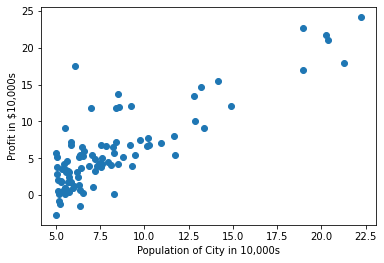

In [2]:
data = pd.read_csv('ex1data1.txt', header = None)
X = data.iloc[:, 0]
y = data.iloc[:, 1]
plt.scatter(X, y)
plt.xlabel("Population of City in 10,000s")
plt.ylabel("Profit in $10,000s")
plt.show()

## Train Model

In [3]:
m_current = 0
b_current = 0
learning_rate = 0.01
epochs = 1500
N = float(len(y))
cost_history, m_history, b_history = [], [], []

In [4]:
def cost_function(y, y_current):
    return sum([data**2 for data in (y-y_current)]) / N

In [5]:

def gradient_descent(m_current, b_current, learning_rate, epochs):
    for i in range(epochs):
        y_current = (m_current * X) + b_current
        cost = cost_function(y, y_current)
        m_gradient = -(2/N) * sum(X * (y - y_current))
        b_gradient = -(2/N) * sum(y - y_current)
        m_current = m_current - (learning_rate * m_gradient)
        b_current = b_current - (learning_rate * b_gradient)
        m_history.append(m_current)
        b_history.append(b_current)
        cost_history.append(cost)
        return m_current, b_current, cost
    
m_current, b_current, cost = gradient_descent(m_current, b_current, learning_rate, epochs)
print ("The cost is:", cost)

The cost is: 64.14546775491131


## Make Prediction for area of 35000 and 70000 people

In [6]:
def predict(x):
    return x*m_current + b_current

In [7]:
print('For population = 35,000, we predict a profit of ', predict(3.5)*10000);
print('For population = 70,000, we predict a profit of ', predict(7.0)*10000);

For population = 35,000, we predict a profit of  46898.02183219899
For population = 70,000, we predict a profit of  92628.2166540887


## Gradient Contour

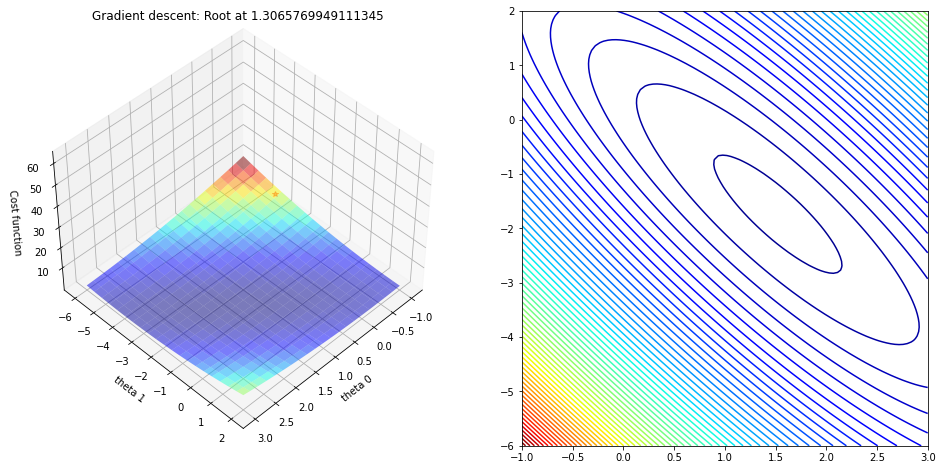

In [8]:
def costfunction(X,y,theta):
    m = np.size(y)
    h = X @ theta
    J = float((1./(2*m)) * (h - y).T @ (h - y));    
    return J;

x = np.linspace(0,1,40)
noise = 1*np.random.uniform(  size = 40)
y = np.sin(x * 1.5 * np.pi ) 
y_noise = (y + noise).reshape(-1,1)
X = np.vstack((np.ones(len(x)),x)).T


#Setup of meshgrid of theta values
T0, T1 = np.meshgrid(np.linspace(-1,3,100),np.linspace(-6,2,100))

#Computing the cost function for each theta combination
zs = np.array(  [costfunction(X, y_noise.reshape(-1,1),np.array([t0,t1]).reshape(-1,1)) 
                     for t0, t1 in zip(np.ravel(T0), np.ravel(T1)) ] )
#Reshaping the cost values    
Z = zs.reshape(T0.shape)

#Computing the gradient descent
theta_result,J_history, theta_0, theta_1 = m_current, cost_history, m_history, b_history

#Angles needed for quiver plot
anglesx = np.array(theta_0)[1:] - np.array(theta_0)[:-1]
anglesy = np.array(theta_1)[1:] - np.array(theta_1)[:-1]

fig = plt.figure(figsize = (16,8))

#Surface plot
ax = fig.add_subplot(1, 2, 1, projection='3d')
ax.plot_surface(T0, T1, Z, rstride = 5, cstride = 5, cmap = 'jet', alpha=0.5)
ax.plot(theta_0,theta_1,J_history, marker = '*', color = 'r', alpha = .4, label = 'Gradient descent')

ax.set_xlabel('theta 0')
ax.set_ylabel('theta 1')
ax.set_zlabel('Cost function')
ax.set_title('Gradient descent: Root at {}'.format(theta_result))
ax.view_init(45, 45)

#Contour plot
ax = fig.add_subplot(1, 2, 2)
ax.contour(T0, T1, Z, 70, cmap = 'jet')
ax.quiver(theta_0[:-1], theta_1[:-1], anglesx, anglesy, scale_units = 'xy', angles = 'xy', scale = 1, color = 'r', alpha = .9)

plt.show()

# Building ML Model: Multi Variable

## Load Data

In [ ]:
house_data = pd.read_csv('ex1data2.txt', header = None, names=['Size(Suqare feet)', 'No of Bedrooms', 'Price'])
X_data = house_data.drop(columns='Price')
y_data = house_data.iloc[:, 2]

X_real, y_real = X_data.copy(), y_data.copy()
sequence_containing_x_vals = list(X_data["Size(Suqare feet)"])
sequence_containing_y_vals = list(X_data["No of Bedrooms"])
sequence_containing_z_vals = list(y_data)
fig = plt.figure()
ax = Axes3D(fig)
ax.scatter(sequence_containing_x_vals, sequence_containing_y_vals,
           sequence_containing_z_vals, color="g")
ax.set_xlabel('Living Room Area', fontsize=10)
ax.set_ylabel('Number of Bed Rooms', fontsize=10)
ax.set_zlabel('Actual Housing Price', fontsize=10)

X_data["Size(Suqare feet)"] = X_data["Size(Suqare feet)"]/np.max(X_data["Size(Suqare feet)"])
X_data["No of Bedrooms"] = X_data["No of Bedrooms"]/np.max(X_data["No of Bedrooms"])
X_data = X_data.values


In [ ]:
house_data.head()

## Train Model

In [ ]:
theta = np.array([0]*X_data.shape[1])
m = len(house_data)
n = X_data.shape[1]

In [ ]:
def hypothesis(theta, X, n):
    h = np.ones((X.shape[0],1))
    theta = theta.reshape(1,n+1)
    for i in range(0,X.shape[0]):
        h[i] = float(np.matmul(theta, X[i]))
    h = h.reshape(X.shape[0])
    return h

In [ ]:
def BGD(theta, alpha, num_iters, h, X, y, n):
    cost = np.ones(num_iters)
    for i in tqdm(range(0,num_iters)):
        theta[0] = theta[0] - (alpha/X.shape[0]) * sum(h - y)
        for j in range(1,n+1):
            theta[j] = theta[j] - (alpha/X.shape[0]) * sum((h-y) * X.transpose()[j])
        h = hypothesis(theta, X, n)
        cost[i] = (1/X.shape[0]) * 0.5 * sum(np.square(h - y))
    theta = theta.reshape(1,n+1)
    return theta, cost

In [ ]:
def linear_regression_multivariate(X, y, alpha, num_iters):
    one_column = np.ones((X.shape[0],1))
    X = np.concatenate((one_column, X), axis = 1)
    theta = np.zeros(n+1)
    h = hypothesis(theta, X, n)
    theta, cost = BGD(theta,alpha,num_iters,h,X,y,n)
    return theta, cost

In [ ]:
theta, cost = linear_regression_multivariate(X_data, y_data, 0.001, 500000)
print(theta)

In [ ]:
import matplotlib.pyplot as plt
cost = list(cost)
n_iterations = [x for x in range(1,500001)]
plt.plot(n_iterations, cost)
plt.xlabel('No. of iterations')
plt.ylabel('Cost')

## Visualize

In [ ]:
X_data_for_pred = np.concatenate((np.ones((X_data.shape[0],1)), X_data), axis = 1)
predictions = hypothesis(theta, X_data_for_pred, X_data_for_pred.shape[1] - 1)
sequence_containing_x_vals = list(X_data_for_pred.transpose()[1])
sequence_containing_y_vals = list(X_data_for_pred.transpose()[2])
sequence_containing_z_vals_pred = list(predictions)
sequence_containing_z_vals = list(y_data)

fig = plt.figure()
ax = Axes3D(fig)
ax.scatter(sequence_containing_x_vals, sequence_containing_y_vals,
           sequence_containing_z_vals_pred, color="r")
ax.scatter(sequence_containing_x_vals, sequence_containing_y_vals,
           sequence_containing_z_vals, color="g")

ax.set_xlabel('Living Room Area', fontsize=10)
ax.set_ylabel('Number of Bed Rooms', fontsize=10)
ax.set_zlabel('Housing Price Predictions', fontsize=10)

## Predict

In [ ]:
area = 1000
bedrooms = 3
result = hypothesis(theta, np.array(list([1.0, area/np.max(X_real["Size(Suqare feet)"]), bedrooms/np.max(X_real["No of Bedrooms"])])).reshape(1, -1), 2)[0]
result